# Importações

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [34]:
df = pd.read_csv("../data/german_credit_data.csv")

df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


# Análise inicial do nosso dataframe

## 5 primeiras e últimas linhas

In [35]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [36]:
df.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,999,27,male,2,own,moderate,moderate,4576,45,car,good


## Verificando as colunas do dataset

In [37]:
print(f'Colunas do dataset: {df.columns}')

Colunas do dataset: Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')


**Significado de cada coluna**

- ***Unnamed: 0*** coluna para identificar cada pessoa do dataset
- ***Age:*** idade (integer)
- ***Sex:*** sexualidade (binária)
- ***Job:*** nível de qualificação profissional (0 -> desempregado, 1 -> não qualificado, 2 -> qualificado, 3 -> altamente qualificado) (one-hot-encoding)
- ***Housing:*** situação de moradia (one-hot-encoding)
- ***Saving account:*** saldo da conta na poupança (one-hot-encoding)
- ***Checking account:*** saldo na conta corrente (one-hot-encoding)
- ***Credit amount:*** valor do empréstimo (float)
- ***Duration:*** duração do empréstimo em meses (int)
- ***Purpose:*** propósito do empréstimo (one-hot-encoding)
- ***Risk:*** risco do cliente ser um bom ou mau pagador (target)


In [38]:
colunas_categoricas = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

for coluna in colunas_categoricas:
    print(f'Valores na coluna {coluna}: {df[coluna].unique()}')
    print()

Valores na coluna Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str

Valores na coluna Job: [2 1 3 0]

Valores na coluna Housing: <StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str

Valores na coluna Saving accounts: <StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

Valores na coluna Checking account: <StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

Valores na coluna Purpose: <StringArray>
[           'radio/TV',           'education', 'furniture/equipment',
                 'car',            'business', 'domestic appliances',
             'repairs',     'vacation/others']
Length: 8, dtype: str



In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [40]:
# Quantidade de linhas e colunas no dataframe
df.shape

(1000, 11)

In [41]:
print(df.describe())

        Unnamed: 0          Age          Job  Credit amount     Duration
count  1000.000000  1000.000000  1000.000000    1000.000000  1000.000000
mean    499.500000    35.546000     1.904000    3271.258000    20.903000
std     288.819436    11.375469     0.653614    2822.736876    12.058814
min       0.000000    19.000000     0.000000     250.000000     4.000000
25%     249.750000    27.000000     2.000000    1365.500000    12.000000
50%     499.500000    33.000000     2.000000    2319.500000    18.000000
75%     749.250000    42.000000     2.000000    3972.250000    24.000000
max     999.000000    75.000000     3.000000   18424.000000    72.000000


In [42]:
df.dtypes

Unnamed: 0          int64
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

- Credit amount: int -> float

In [43]:
for coluna in colunas_categoricas:
  print(f"\n==== Frequência dos valores da coluna: {coluna} ====")
  print(df[coluna].value_counts())


==== Frequência dos valores da coluna: Sex ====
Sex
male      690
female    310
Name: count, dtype: int64

==== Frequência dos valores da coluna: Job ====
Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64

==== Frequência dos valores da coluna: Housing ====
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

==== Frequência dos valores da coluna: Saving accounts ====
Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

==== Frequência dos valores da coluna: Checking account ====
Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64

==== Frequência dos valores da coluna: Purpose ====
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64


# Análise estatística

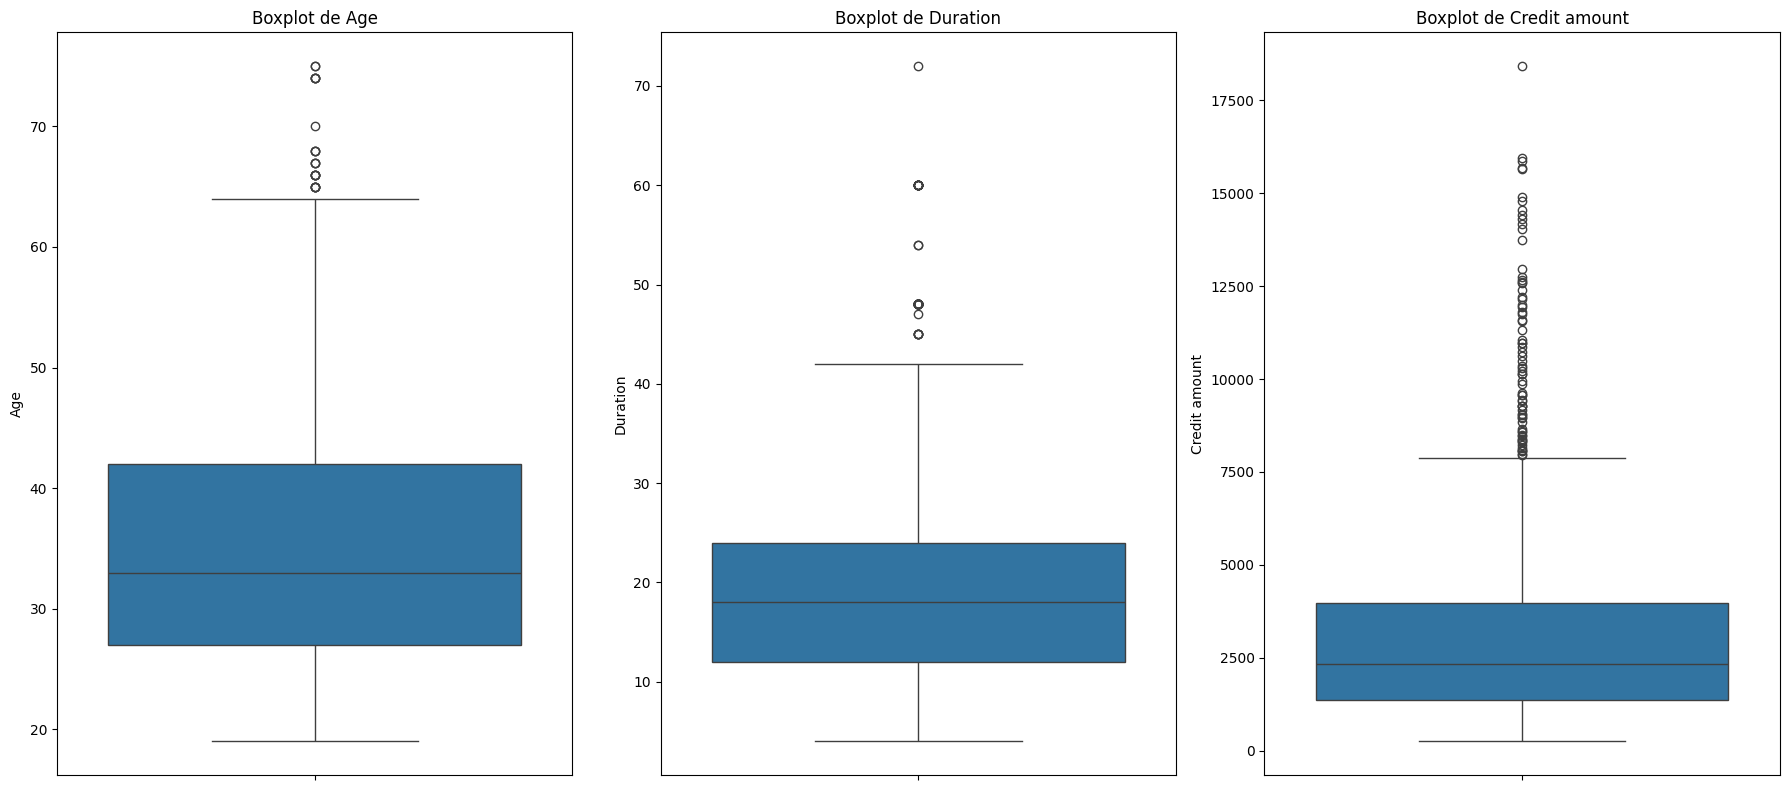

In [44]:
colunas_numericas = ['Age', 'Duration', 'Credit amount']

# Número de linhas e colunas
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 8))

# Boxplot de 'tenure'
sns.boxplot(y=df['Age'], ax=ax[0])
ax[0].set_title('Boxplot de Age')

# Boxplot de 'MonthlyCharges'
sns.boxplot(y=df['Duration'], ax=ax[1])
ax[1].set_title('Boxplot de Duration')

# Boxplot de 'Credit amount'
sns.boxplot(y=df['Credit amount'], ax=ax[2])
ax[2].set_title('Boxplot de Credit amount')


plt.tight_layout()
plt.show()

### **Conclusões:**

- ***Age:***
    - possui uma assimetria positiva.
    - mediana em torno de 32 anos.
    - outliers acima de 65 anos.
    - a assimetria positiva indica que há mais clientes jovens do que velhos.

- ***Duration:***
    - mediana em torno de 18 meses, maioria dos empréstimos é de curto prazo.
    - gráfico simétrico.
    - outliers acima de 60 meses.

- ***Credit amount:***
    - mediana em torno de 2300.
    - mediana bem próxima do Q1, assimetria positiva forte.
    - mais assimétrica, o que justifica a transformação logarítmica.

# Limpeza dos dados

## Tratando os valores nulos

In [45]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Dado o contexto do dataset, o motivo mais plausível para os valores nulos existirem nas colunas Saving e Checking account é o fato dos clientes não terem essa conta, e não por terem esquecido de preencher.

O cliente não ter uma conta corrente ou poupança é uma informação valiosa para o negócio, o que torna viável a criação de uma nova categoria para essas pessoas que não possuem estas.

Devido a quantidade de valores nulos dropar as linhas resultaria na perda de grande parte dos dados do dataset.

Preencher com a moda seria inventar uma informação que não existe.

Dropar a coluna resultaria na perda de duas das colunas mais valiosas para o modelo.

In [46]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')

## Lidando com os outliers 

### Coluna 'Age'

Apesar de existirem outliers, ainda são pessoas reais, idosos existem e pedem créditos. Não serão removidos

### Coluna 'Duration'

Prazos longos para empréstimos são totalmente comuns. Não serão removidos

### Coluna 'Credit amount'

In [47]:
q1 = df['Credit amount'].quantile(0.25) # calculando o primeiro quartil
q3 = df['Credit amount'].quantile(0.75) # calculando o terceiro quartil
iqr = q3 - q1 # calculando o intervalo interquartil (terceiro quartil - primeiro quartil)

outliers = df[df['Credit amount'] > q3 + 1.5 * iqr] # definindo o valor para ser considerado um outlier
print(f"Quantidade de outliers: {len(outliers)}") # número de outliers
print(f"Percentual do dataset: {len(outliers)/len(df):.1%}") # percentual de outliers no dataframe

Quantidade de outliers: 72
Percentual do dataset: 7.2%


Devido à grande quantidade de outliers, ao invés de remover os valores nulos, a melhor opção é aplicar uma transformação logarítmica que reduz o peso dos valores extremos sem perder os dados.

In [48]:
df['Credit amount'] = np.log1p(df['Credit amount'])

Diferença após a transformação

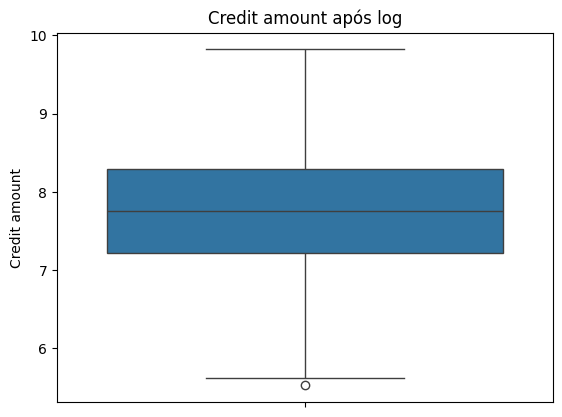

In [49]:
sns.boxplot(y=df['Credit amount'])
plt.title('Credit amount após log')
plt.show()

# Transformação dos dados

In [50]:
print(f'Colunas categóricas: {colunas_categoricas}')

Colunas categóricas: ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [51]:
for coluna in colunas_categoricas:
    print(f'Valores das colunas categóricas: {df[coluna].unique()}')
    print()

Valores das colunas categóricas: <StringArray>
['male', 'female']
Length: 2, dtype: str

Valores das colunas categóricas: [2 1 3 0]

Valores das colunas categóricas: <StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str

Valores das colunas categóricas: <StringArray>
['none', 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

Valores das colunas categóricas: <StringArray>
['little', 'moderate', 'none', 'rich']
Length: 4, dtype: str

Valores das colunas categóricas: <StringArray>
[           'radio/TV',           'education', 'furniture/equipment',
                 'car',            'business', 'domestic appliances',
             'repairs',     'vacation/others']
Length: 8, dtype: str



In [52]:
print(f'==== Tipos das colunas ====')
print(df.dtypes)

==== Tipos das colunas ====
Unnamed: 0            int64
Age                   int64
Sex                     str
Job                   int64
Housing                 str
Saving accounts         str
Checking account        str
Credit amount       float64
Duration              int64
Purpose                 str
Risk                    str
dtype: object


Todas as colunas estão com seus devidos tipos

# Análise Exploratória dos Dados (EDA)

## Matriz de correlação

<Axes: >

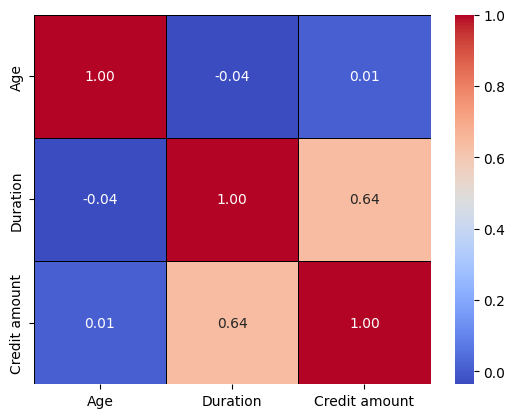

In [53]:
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, linecolor='black')

**Conclusões:**

- as relações 'Age' x 'Credit amount' e 'Duration' x 'Age' tem baixíssima correlação.
- a duração do empréstimo e o valor a ser emprestado são bem correlacionados, o que faz bastante sentido, visto que quanto maior o valor emprestado maior será o tempo necessário para pagá-lo.

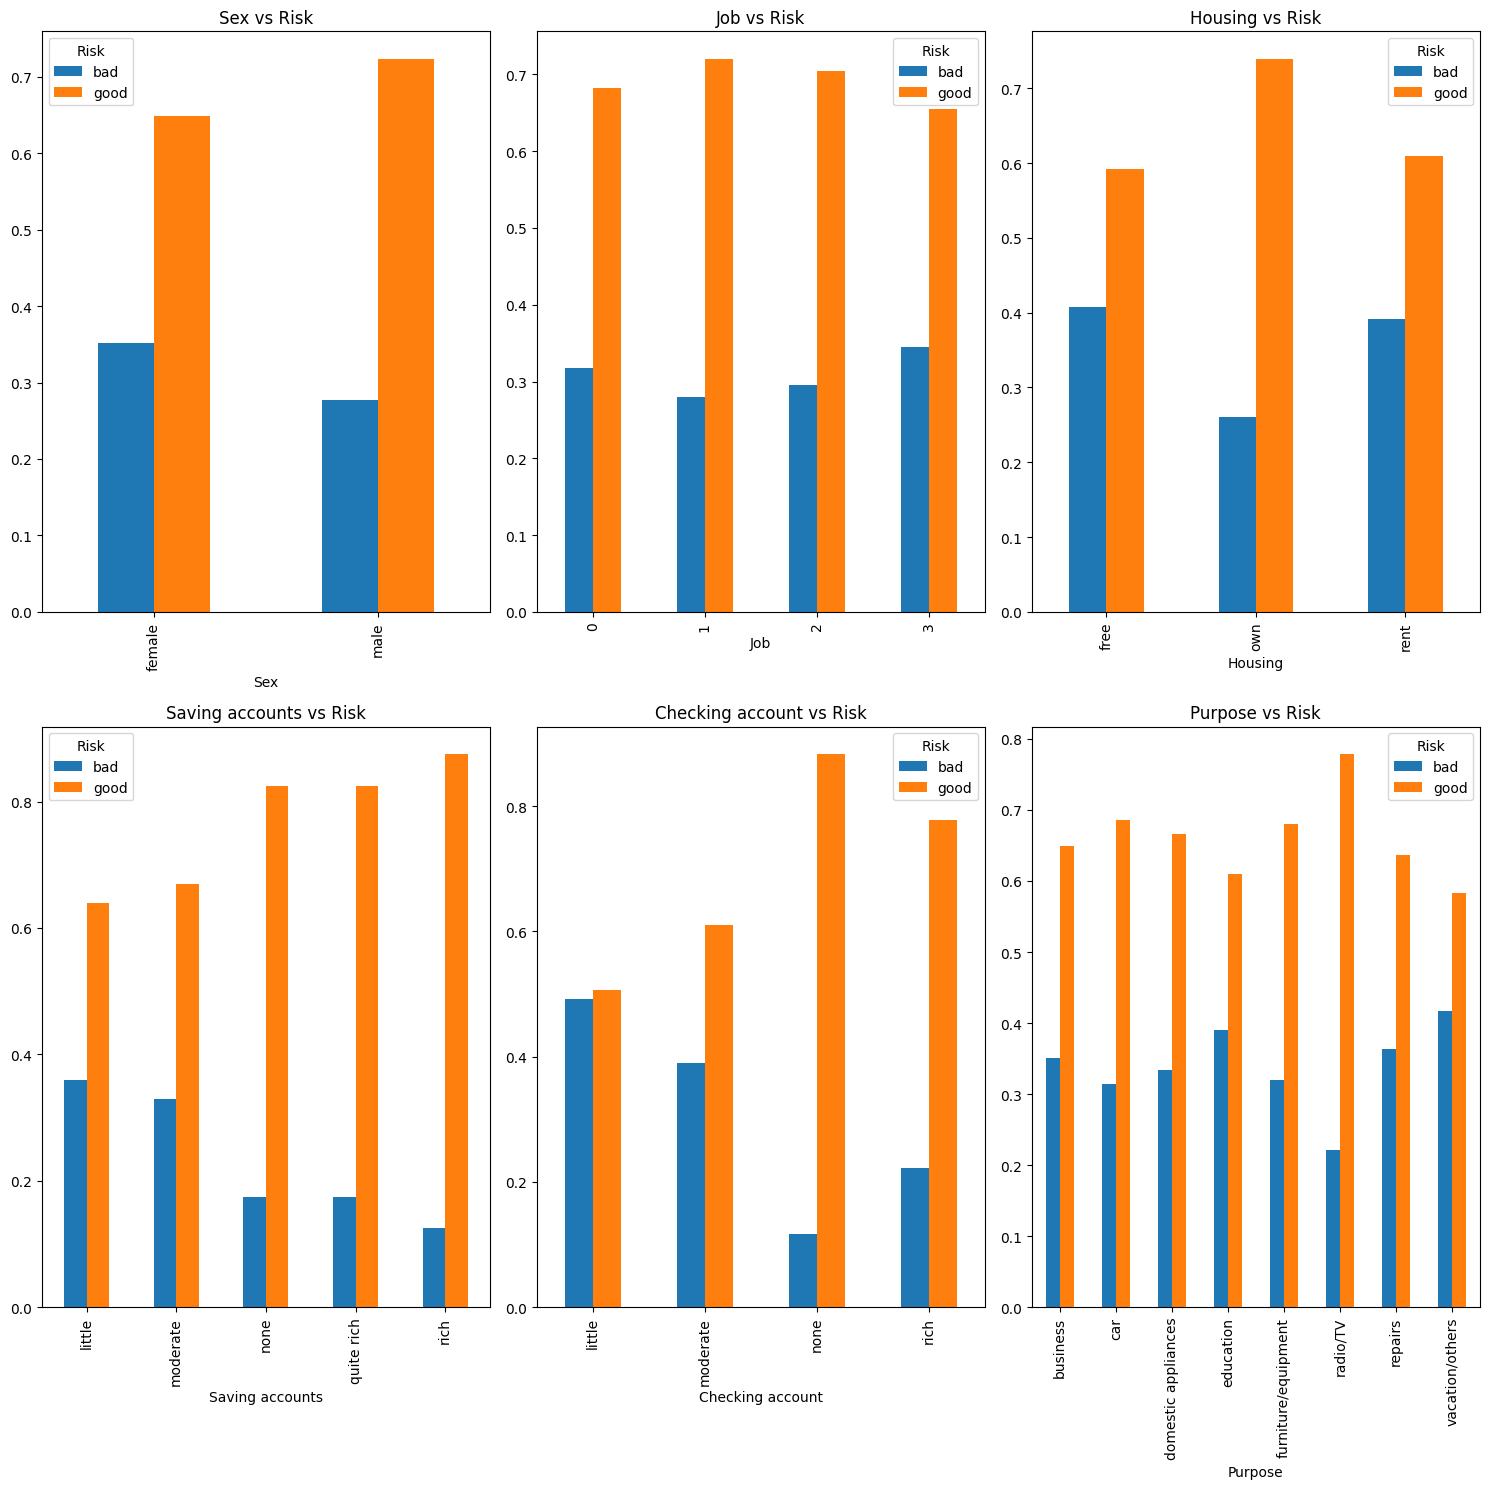

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(15, 15))
axes = axes.flatten()

colunas_sem_churn = [col for col in colunas_categoricas if col != 'Risk']

for i, col in enumerate(colunas_sem_churn):
    df.groupby(col)['Risk'].value_counts(normalize=True).unstack().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} vs Risk')

plt.tight_layout()
plt.show()

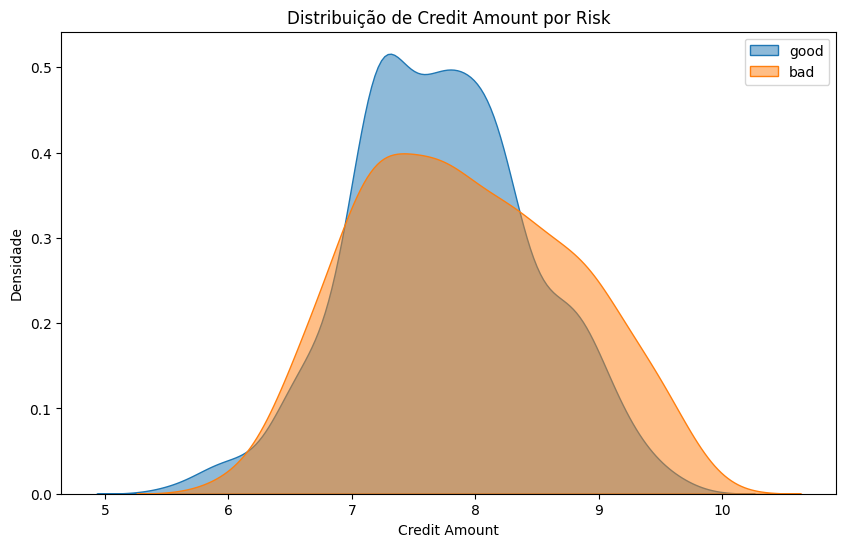

In [55]:
plt.figure(figsize=(10, 6))

for risk in df['Risk'].unique():
    subset = df[df['Risk'] == risk]
    sns.kdeplot(subset['Credit amount'], label=risk, fill=True, alpha=0.5)

plt.title('Distribuição de Credit Amount por Risk')
plt.xlabel('Credit Amount')
plt.ylabel('Densidade')
plt.legend()
plt.show()

**Conclusões:**

- ***Bons pagadores (azul):***
    - pico mais alto em torno de 7.3. Mais concentrados em valores baixos/médios de crédito.
    - cauda direita curta. Poucos bons pagadores pedem valores muito altos.

- ***Maus pagadores (laranja):***
    - distribuição mais larga e achatada
    - cauda direita mais longa. Maus pagadores tendem a solicitar valores mais altos.
    - pico menor, indicando menos concentração num valore específico.

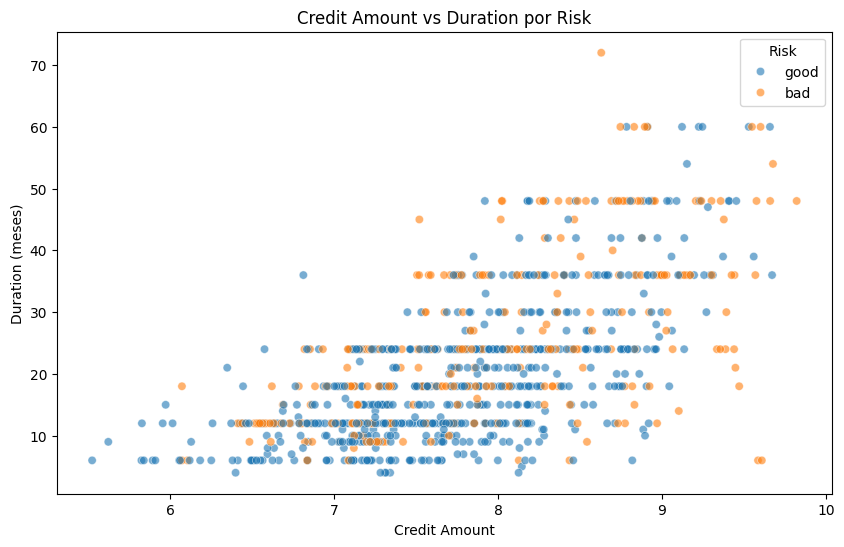

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Credit amount',
    y='Duration',
    hue='Risk',
    alpha=0.6
)

plt.title('Credit Amount vs Duration por Risk')
plt.xlabel('Credit Amount')
plt.ylabel('Duration (meses)')
plt.show()

**Conclusões:**

- ***Região de baixo risco (esquerda/baixo):***
    - crédito baixo + prazo curto -> predominância de bons pagadores (azul).
    - quem pede pouco e quer pagar rápido tem mais chance de honrar o compromisso.

- ***Região de alto risco (direita/cima):***
    - crédito alto + prazo longo -> muito mais pontos laranja misturados com azul.
    - quanto mais à direita e mais para cima, maior a proporção de maus pagadores.

- ***Correlação positiva entre as duas variáveis:***
    - existe uma tendência clara. Quem pede mais crédito também pede mais prazo para pagar.
    - faz sentido: empréstimos maiores precisam de parcelas menores para caber no orçamento. 

# Feature engineering

## Transformando a coluna 'Job'

Ao invés delas serem apenas números vou transformá-las nos seus significados para melhor visualização

In [57]:
job_map = {
    0: 'unskilled non-resident',
    1: 'unskilled resident',
    2: 'skilled',
    3: 'highly skilled'
}

df['Job'] = df['Job'].map(job_map)

## Transformando as colunas binárias

In [58]:
for coluna in colunas_categoricas:
    print(f'{coluna}: {df[coluna].unique()}')
    print()

Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str

Job: <StringArray>
['skilled', 'unskilled resident', 'highly skilled', 'unskilled non-resident']
Length: 4, dtype: str

Housing: <StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str

Saving accounts: <StringArray>
['none', 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

Checking account: <StringArray>
['little', 'moderate', 'none', 'rich']
Length: 4, dtype: str

Purpose: <StringArray>
[           'radio/TV',           'education', 'furniture/equipment',
                 'car',            'business', 'domestic appliances',
             'repairs',     'vacation/others']
Length: 8, dtype: str



In [59]:
# Transformando as colunas categóricas de dois valores em flag binária

df['Sex'] = df['Sex'].replace({'female': 1, 'male': 0})
df['Risk'] = df['Risk'].replace({'good': 1, 'bad': 0})

In [60]:
# As colunas categóricas que possuem mais de 2 valores possíveis é feito o 'get_dummies', em que cada valor ganha uma coluna própria que caso o valor seja True ele vira 1

colunas_categoricas_3_valores = ['Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

for coluna in colunas_categoricas_3_valores:
    df = pd.get_dummies(df, columns=[coluna], dtype=int)

In [61]:
# A coluna 'Unnamed: 0' foi dropada pelo fato de ser uma coluna utilizada apenas para identificação e não colaborar para a previsão do target
df = df.drop(columns='Unnamed: 0')

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          1000 non-null   int64  
 1   Sex                          1000 non-null   object 
 2   Credit amount                1000 non-null   float64
 3   Duration                     1000 non-null   int64  
 4   Risk                         1000 non-null   object 
 5   Job_highly skilled           1000 non-null   int64  
 6   Job_skilled                  1000 non-null   int64  
 7   Job_unskilled non-resident   1000 non-null   int64  
 8   Job_unskilled resident       1000 non-null   int64  
 9   Housing_free                 1000 non-null   int64  
 10  Housing_own                  1000 non-null   int64  
 11  Housing_rent                 1000 non-null   int64  
 12  Saving accounts_little       1000 non-null   int64  
 13  Saving accounts_moderate     1

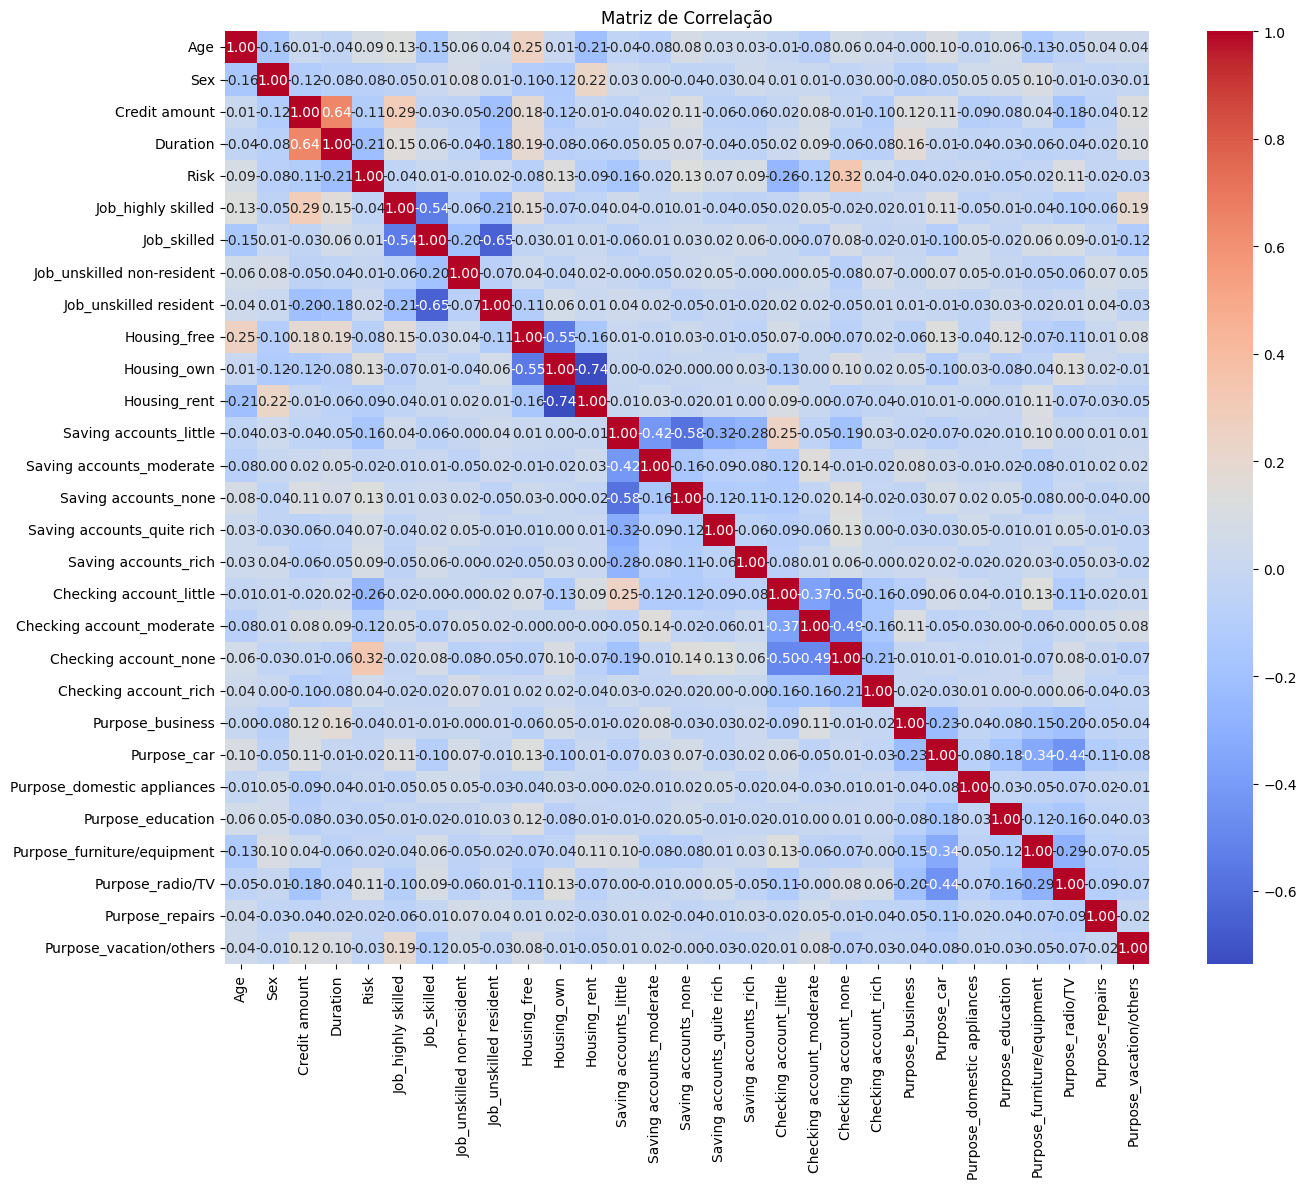

In [64]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

**Conclusões:**

- Credit amount e Duration: 0.64 -> quem pede mais crédito tende a pedir mais prazo — já víamos isso no scatter plot
- Job_skilled e Job_unskilled resident: -0.54 -> esperado, são categorias opostas do get_dummies
- Housing_own e Housing_rent: -0.74 -> mesma lógica
- Checking account_none: 0.32 -> clientes sem conta corrente têm mais risco
- Checking account_little: 0.26 -> pouco saldo na conta corrente também indica risco
- Checking account_rich: -0.32 -> conta corrente rica reduz o risco
- Saving accounts_little: 0.28 -> pouca poupança aumenta o risco
- Duration: 0.21 -> prazo longo aumenta o risco
- Credit amount: 0.21 -> valor alto aumenta o risco

In [65]:
df = df.drop(columns=['Sex'])

In [66]:
df.to_csv('../data/CreditRiskCleanDataset.csv', index=False)